# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             classification_report,
                             f1_score,
                             confusion_matrix)
print('Libraries Loaded Boss✅')

Libraries Loaded Boss✅


# **Data Exploration**

## *Load The Data*

In [3]:
File_path = input("Enter The File Path: ").replace('\\','\\')
df = pd.read_csv(File_path)
print('Data Loaded Boss👍')

Data Loaded Boss👍


## *Exploration*

In [5]:
print(f"The Dataset have {df.shape[0]} Rows and {df.shape[1]} columns")

The Dataset have 593 Rows and 8 columns


In [7]:
df.head()

,runs_first_6_overs,wickets_lost_pp,current_run_rate,boundary_count,home_venue,top3_batsmen_in,extras_conceded,match_won
0,31.0,3.0,NaN,2.0,0.0,1.0,3.0,0
1,68.0,4.0,9.58,9.0,1.0,0.0,19.0,0
2,80.0,4.0,5.74,2.0,1.0,1.0,19.0,0
3,75.0,3.0,11.62,2.0,1.0,1.0,5.0,1
4,48.0,3.0,9.92,11.0,1.0,1.0,0.0,1


In [8]:
df.tail()

,runs_first_6_overs,wickets_lost_pp,current_run_rate,boundary_count,home_venue,top3_batsmen_in,extras_conceded,match_won
588,62.0,4.0,6.73,6.0,0.0,1.0,10.0,0
589,55.0,4.0,13.47,11.0,0.0,1.0,10.0,0
590,65.0,0.0,5.64,6.0,0.0,0.0,18.0,0
591,46.0,4.0,8.53,16.0,0.0,1.0,17.0,0
592,75.0,4.0,14.0,10.0,1.0,0.0,7.0,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 593 entries, 0 to 592
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   runs_first_6_overs  593 non-null    float64
 1   wickets_lost_pp     593 non-null    float64
 2   current_run_rate    575 non-null    str    
 3   boundary_count      576 non-null    float64
 4   home_venue          593 non-null    float64
 5   top3_batsmen_in     593 non-null    float64
 6   extras_conceded     593 non-null    float64
 7   match_won           593 non-null    int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 39.7 KB


In [10]:
df.describe()

,runs_first_6_overs,wickets_lost_pp,boundary_count,home_venue,top3_batsmen_in,extras_conceded,match_won
count,593.000000,593.000000,576.000000,593.000000,593.000000,593.000000,593.000000
mean,59.210793,1.865093,10.210069,0.559865,0.583474,9.983137,0.699831
std,25.119399,1.436263,4.967649,0.496822,0.493399,13.263814,0.458718
min,30.000000,-2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,43.000000,1.000000,6.000000,0.000000,0.000000,4.000000,0.000000
50%,58.000000,2.000000,10.000000,1.000000,1.000000,9.000000,1.000000
75%,74.000000,3.000000,14.000000,1.000000,1.000000,15.000000,1.000000
max,500.000000,4.000000,19.000000,1.000000,1.000000,300.000000,1.000000


In [17]:
print(f'The NaN values in the dataset is as follows: ')
df.isna().sum()

The NaN values in the dataset is as follows: 


runs_first_6_overs     0
wickets_lost_pp        0
current_run_rate      18
boundary_count        17
home_venue             0
top3_batsmen_in        0
extras_conceded        0
match_won              0
dtype: int64

In [19]:
print('The Dataset Contains',df.duplicated().sum(),'Duplicates')

The Dataset Contains 12 Duplicates


# **Data Cleaning**

**Creating Copy**

In [11]:
df_copy = df.copy()
print('Copy Created Boss')

Copy Created Boss


**Data Type Correction**

In [12]:
df_copy['current_run_rate'] = df_copy['current_run_rate'].replace('_err','',regex=True).astype('float')

**Outliers**

In [22]:
outliers_columns = ['runs_first_6_overs','extras_conceded']

for col in outliers_columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


**Duplicates**

In [23]:
print('Duplicates in the data is:',df_copy.duplicated().sum())
df_copy.drop_duplicates(inplace=True)
print('Duplicates in the data after cleaning is:',df_copy.duplicated().sum())

Duplicates in the data is: 13
Duplicates in the data after cleaning is: 0


In [ ]:
print(f'The NaN values in the Dataset before Cleaning is: ')
print(df_copy.isna().sum())
columns = df_copy.columns.tolist()
for col in columns:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
print('\nNaN Values After Cleaning is: ')
print(df_copy.isna().sum())

The NaN values in the Dataset before Cleaning is: 
runs_first_6_overs     1
wickets_lost_pp        0
current_run_rate      18
boundary_count        17
home_venue             0
top3_batsmen_in        0
extras_conceded        1
match_won              0
dtype: int64

NaN Values After Cleaning is: 

runs_first_6_overs    0
wickets_lost_pp       0
current_run_rate      0
boundary_count        0
home_venue            0
top3_batsmen_in       0
extras_conceded       0
match_won             0
dtype: int64


**Confirmation**

In [27]:
print(f'The shape of the dataset after Cleaning is {df_copy.shape}')

The shape of the dataset after Cleaning is (580, 8)


# **Data Preperation**

In [28]:
X = df_copy[['runs_first_6_overs',
        'runs_first_6_overs',
        'current_run_rate',
        'boundary_count',
        'home_venue',
        'top3_batsmen_in',
        'extras_conceded']]

y = df_copy['match_won']

print(f"X shape: {X.shape}")
print(f'y Shape: {y.shape}')

X shape: (580, 7)
y Shape: (580,)


In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)


print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')

X_train shape: (464, 7)
y_train Shape: (464,)
X_test Shape: (116, 7)
y_test Shape: (116,)


# **Model**

## *Train*

In [32]:
model = LogisticRegression()

model.fit(X_train,y_train)

print('Model Trained boss👍')

Model Trained boss👍


## *Test*

In [35]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

comparison = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_pred,
    'Probability': y_prob.round(3)
})
print(comparison.head(10))

   Actual  Predicted  Probability
0       0          1        0.842
1       1          1        0.512
2       1          1        0.976
3       1          1        0.719
4       0          0        0.293
5       0          0        0.084
6       0          1        0.637
7       1          1        0.948
8       1          1        0.987
9       0          1        0.615


## *Model Evaluation*

In [43]:
print(classification_report(y_test,y_pred),'\n')
print(confusion_matrix(y_test,y_pred),'\n')
print(f'Accuracy: {round(accuracy_score(y_test,y_pred),3)}')

              precision    recall  f1-score   support

           0       0.56      0.39      0.46        38
           1       0.74      0.85      0.79        78

    accuracy                           0.70       116
   macro avg       0.65      0.62      0.63       116
weighted avg       0.68      0.70      0.68       116
 

[[15 23]
 [12 66]] 

Accuracy: 0.698


## *Metrics*

In [44]:
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 Score: ", round(f1_score(y_test, y_pred), 4))

Accuracy:  0.6983
Precision: 0.7416
Recall:    0.8462
F1 Score:  0.7904


# **Charts**

**CM**

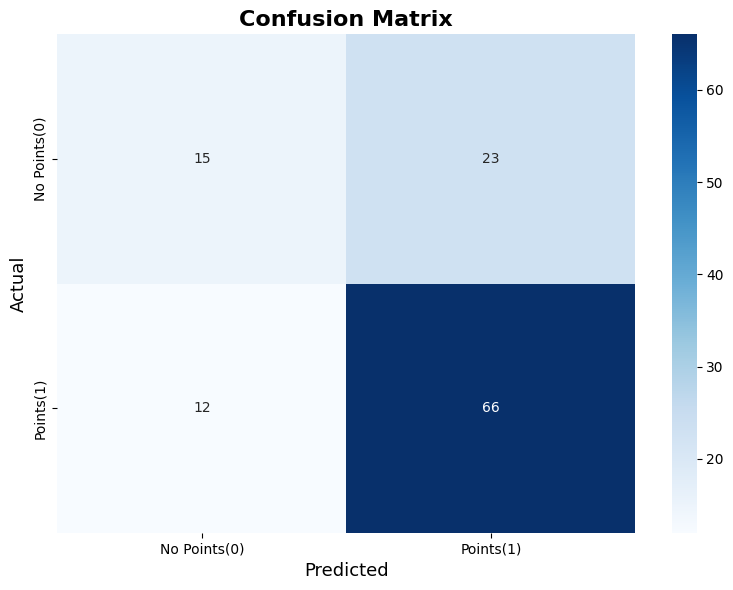

In [52]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Points(0)', 'Points(1)'],
            yticklabels=['No Points(0)', 'Points(1)'])
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**All in One**

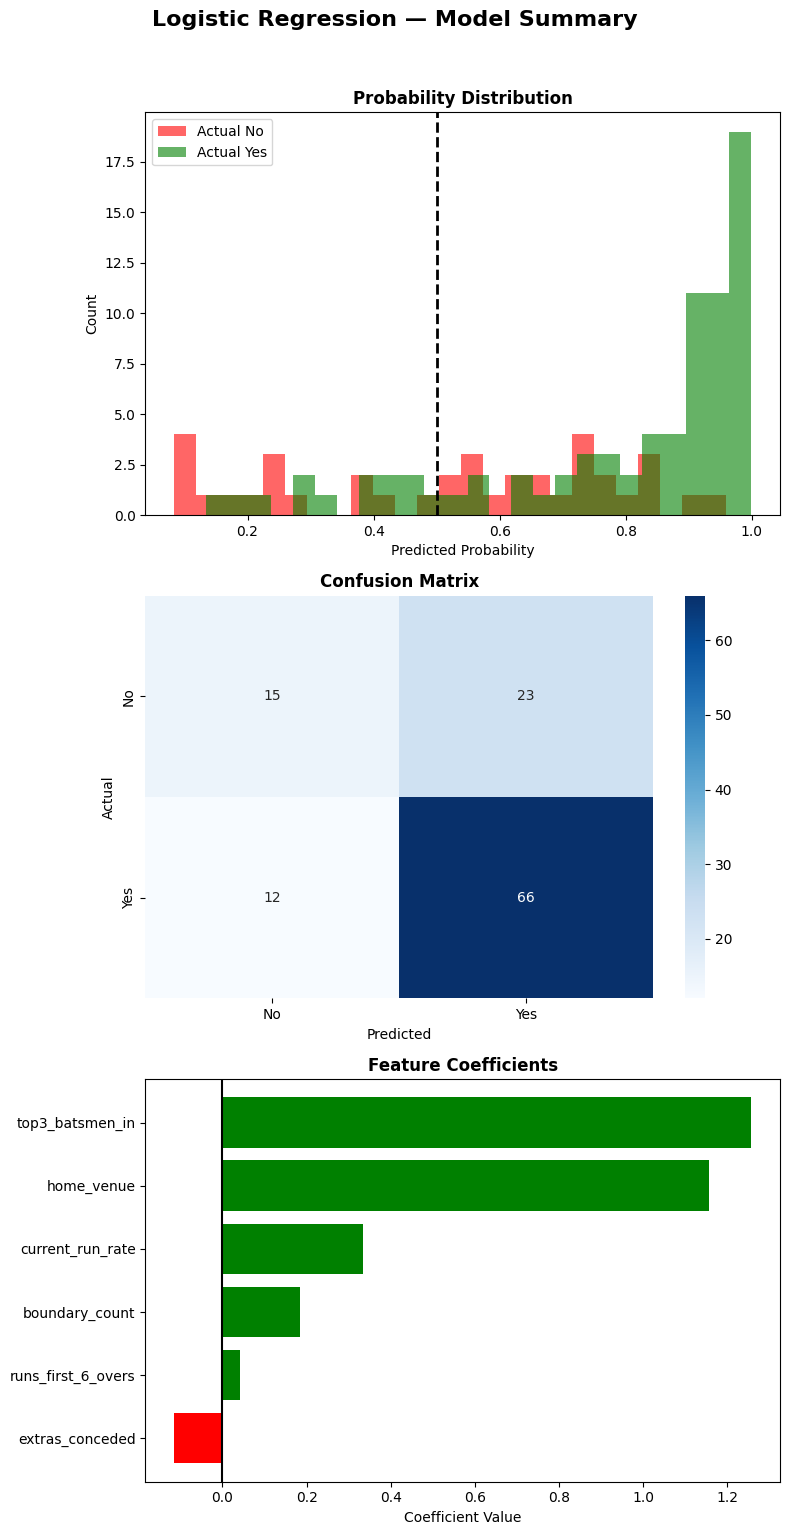

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

# --- Plot 1: Probability Distribution ---
axes[0].hist(y_prob[y_test == 0], bins=25, alpha=0.6,
             color='red', label='Actual No')
axes[0].hist(y_prob[y_test == 1], bins=25, alpha=0.6,
             color='green', label='Actual Yes')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Plot 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# --- Plot 3: Feature Coefficients ---
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[2].axvline(x=0, color='black', linewidth=1.5)
axes[2].set_title('Feature Coefficients', fontweight='bold')
axes[2].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression — Model Summary', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
